In [1]:
import mmd
tracks = mmd.MIDITrack.load_from_file(path='data/MMD_scraped_genre.jsonl')

In [2]:
def remove_genres(tracks: list[mmd.MIDITrack], genres = [], min_count = 0):
    count = count_genres(tracks)

    for track in tracks:
        for genre in track.genres:
            if genre in genres or count[genre] < min_count:
                track.genres.remove(genre)
    return tracks

def count_genres(tracks: list[mmd.MIDITrack]):
    genres = {}
    for track in tracks:
        for genre in track.genres:
            if genre not in genres:
                genres[genre] = 0
            genres[genre] += 1
    return genres

def filter_no_genres(tracks: list[mmd.MIDITrack]):
    return [track for track in tracks if track.genres]

def replace_genre(tracks: list[mmd.MIDITrack], old_genre, new_genre):
    for track in tracks:
        if old_genre in track.genres:
            track.genres.remove(old_genre)

            if new_genre not in track.genres:
                track.genres.append(new_genre)
    return tracks

def count_genre_counts(tracks: list[mmd.MIDITrack]):
    counts = {}
    for track in tracks:
        count = len(track.genres)
        if count not in counts:
            counts[count] = 0
        counts[count] += 1
    return counts

In [3]:
tracks = replace_genre(tracks, "film", "musical%2cfilm%2ctv")
tracks = replace_genre(tracks, "film/tv", "musical%2cfilm%2ctv")
tracks = replace_genre(tracks, "tv and movie soundtracks", "musical%2cfilm%2ctv")
tracks = replace_genre(tracks, "broadway and stage", "musical%2cfilm%2ctv")
tracks = replace_genre(tracks, "instrumentals", "instrumental")
tracks = replace_genre(tracks, "folk", "traditional")
tracks = replace_genre(tracks, "traditional_(folk)", "traditional")
tracks = replace_genre(tracks, "golden oldies", "oldies")
tracks = replace_genre(tracks, "classic modern rb", "rnb-soul")
tracks = replace_genre(tracks, "classical music", "classical")
tracks = replace_genre(tracks, "hip hop rap", "hip-hop-rap")
tracks = replace_genre(tracks, "bluegrass", "country")
tracks = replace_genre(tracks, "early_20th_century", "early 20th century")
tracks = replace_genre(tracks, "medleys", "medley")
tracks = replace_genre(tracks, "italian", "italian%2cfrench%2cspanish")
tracks = replace_genre(tracks, "french", "italian%2cfrench%2cspanish")


tracks = remove_genres(tracks, [], 200)
tracks = filter_no_genres(tracks)

In [4]:
# Split into train, validation and test
import random
random.seed(42)
random.shuffle(tracks)

TRAIN_SIZE = 0.8
TEST_SIZE = (1 - TRAIN_SIZE) / 2
VALIDATION_SIZE = TEST_SIZE

def save_tracks(tracks, path):
    with open(path, 'w') as f:
        for track in tracks:
            f.write(track.md5 + ',' + track.genres[0] + '\n')

genre_buckets = count_genres(tracks)
for key in genre_buckets.keys():
    genre_buckets[key] = []

for track in tracks:
    genre_buckets[track.genres[0]].append(track)

train_tracks = []
test_tracks = []
validation_tracks = []

for key in genre_buckets.keys():
    temp_tracks = genre_buckets[key]
    train_size = int(len(temp_tracks) * TRAIN_SIZE)
    test_size = int(len(temp_tracks) * TEST_SIZE)

    train_tracks += temp_tracks[:train_size]
    test_tracks += temp_tracks[train_size:train_size + test_size]
    validation_tracks += temp_tracks[train_size + test_size:]
    

save_tracks(train_tracks, 'data/train.csv')
save_tracks(test_tracks, 'data/test.csv')
save_tracks(validation_tracks, 'data/validation.csv')


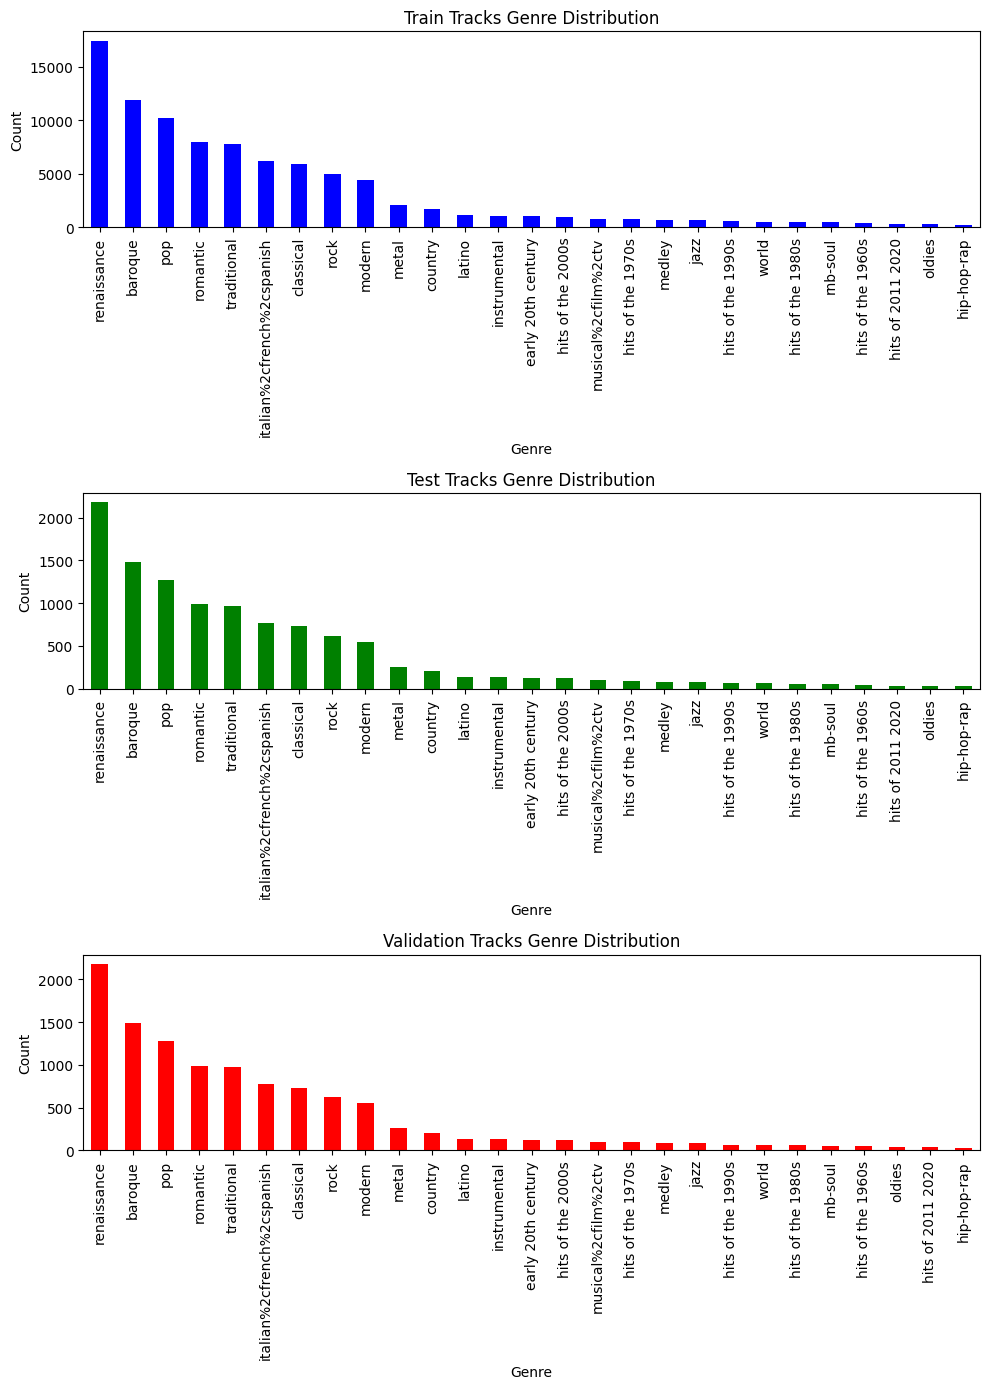

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Count genres in train and test tracks
train_genre_counts = count_genres(train_tracks)
test_genre_counts = count_genres(test_tracks)
validation_genre_counts = count_genres(validation_tracks) 

# Create a dataframe for plotting
df_train = pd.DataFrame(sorted(train_genre_counts.items(), key=lambda x: x[1], reverse=True), columns=['Genre', 'Count'])
df_test = pd.DataFrame(sorted(test_genre_counts.items(), key=lambda x: x[1], reverse=True), columns=['Genre', 'Count'])
df_validation = pd.DataFrame(sorted(validation_genre_counts.items(), key=lambda x: x[1], reverse=True), columns=['Genre', 'Count'])


# Plot the distributions
fig, ax = plt.subplots(3, 1, figsize=(10, 14))

df_train.plot(kind='bar', x='Genre', y='Count', ax=ax[0], color='blue', legend=False)
ax[0].set_title('Train Tracks Genre Distribution')
ax[0].set_ylabel('Count')

df_test.plot(kind='bar', x='Genre', y='Count', ax=ax[1], color='green', legend=False)
ax[1].set_title('Test Tracks Genre Distribution')
ax[1].set_ylabel('Count')

df_validation.plot(kind='bar', x='Genre', y='Count', ax=ax[2], color='red', legend=False)
ax[2].set_title('Validation Tracks Genre Distribution')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
train_loaded = mmd.MIDITrack.load_from_file(path='data/train.csv')
test_loaded = mmd.MIDITrack.load_from_file(path='data/test.csv')
validation_loaded = mmd.MIDITrack.load_from_file(path='data/validation.csv')

assert len(train_loaded) == len(train_tracks)
assert len(test_loaded) == len(test_tracks)
assert len(validation_loaded) == len(validation_tracks)

print(f'Train:       {len(train_loaded)}')
print(f'Test:        {len(test_loaded)}')
print(f'Validation:  {len(validation_loaded)}')

def check_duplicates(tracks):
    seen = set()
    duplicates = set()
    for track in tracks:
        if track.md5 in seen:
            duplicates.add(track.md5)
        else:
            seen.add(track.md5)
    return duplicates

train_duplicates = check_duplicates(train_loaded)
test_duplicates = check_duplicates(test_loaded)
validation_duplicates = check_duplicates(validation_loaded)

print(f'Train duplicates: {len(train_duplicates)}')
print(f'Test duplicates: {len(test_duplicates)}')
print(f'Validation duplicates: {len(validation_duplicates)}')

Train:       90308
Test:        11274
Validation:  11319
Train duplicates: 0
Test duplicates: 0
Validation duplicates: 0
